# Percolation Benchmark Analysis

This notebook is a thin interactive wrapper around `percolation_uart.analysis`.

It keeps the SQLite loading and plotting logic in the analysis module, so the notebook can stay lightweight while you inspect sessions, select a run, and render the standard plots inline.

In [11]:
from __future__ import annotations

import sys
import tempfile
from pathlib import Path

from IPython.display import Image, display

def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'python' / 'percolation_uart' / 'analysis' / '__init__.py').exists():
            return candidate
    raise FileNotFoundError('could not locate repository root')

repo_root = find_repo_root()
python_dir = repo_root / 'python'
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))

from percolation_uart import analysis

db_path = analysis.DEFAULT_DB
plot_dir = repo_root / 'python' / 'output' / 'notebook_analysis'
plot_dir.mkdir(parents=True, exist_ok=True)
db_path, plot_dir

(PosixPath('/home/alessio/ssd_data/Alessio/uni_magistrale/Programmable_Hardware_Devices/FPGA-project/python/output/benchmark.sqlite3'),
 PosixPath('/home/alessio/ssd_data/Alessio/uni_magistrale/Programmable_Hardware_Devices/FPGA-project/python/output/notebook_analysis'))

In [12]:
conn = analysis._connect(db_path)
try:
    sessions = analysis.list_sessions(conn)
    print(analysis.summarize_db(conn))
    print()
    for index, session in enumerate(sessions, start=1):
        payload = session.payload
        print(f'{index:2d}. session_id={session.session_id} created_at={session.created_at}')
        if 'config_hash' in payload:
            print(f'    config_hash={payload["config_hash"]}')
        if 'args' in payload and isinstance(payload['args'], dict):
            args = payload['args']
            print(f'    runs={args.get("runs")} repeats={args.get("repeats")} points={args.get("points")} steps={args.get("steps")}')
finally:
    conn.close()

sessions=76, summary_rows=326, raw_rows=2025, p_range=[0.5500, 0.6500]

 1. session_id=16456613-9b42-426b-8276-77890362f2c0 created_at=2026-05-25T20:17:58.246374+00:00
 2. session_id=1ba9a5c9-dc36-4736-a209-6d4324491537 created_at=2026-05-25T20:18:41.138829+00:00
 3. session_id=d29f84f5-6b43-4a58-bfed-efdf181ab630 created_at=2026-05-25T20:21:41.817020+00:00
 4. session_id=63343d77-c074-4274-ad9a-23cdd97fa8a9 created_at=2026-05-25T20:27:47.064048+00:00
 5. session_id=c06f384a-4963-4285-8ea9-fbd9ef603d10 created_at=2026-05-25T20:33:46.739753+00:00
 6. session_id=4a073f09-93b8-44a8-9571-659a7c06c2dd created_at=2026-05-25T20:35:10.221769+00:00
 7. session_id=f36e3ca2-a7b9-4fff-abe3-9f70fab52ff9 created_at=2026-05-25T20:35:10.749981+00:00
 8. session_id=1a0c32e0-635d-4d32-ac1d-c8acacacb682 created_at=2026-05-25T20:35:11.348073+00:00
 9. session_id=b94ad490-29cc-4994-a9e2-a4f3825d5ab5 created_at=2026-05-25T20:35:11.919958+00:00
10. session_id=e14b5772-7ea3-4426-bd4d-5d1e3240913a created_at=2

In [13]:
selected_session_index = 5-1

conn = analysis._connect(db_path)
try:
    sessions = analysis.list_sessions(conn)
    if not sessions:
        raise RuntimeError(f'no sessions found in {db_path}')
    selected_session = sessions[selected_session_index]
    selected_session_id = selected_session.session_id
    summary_rows = analysis.load_summary_rows(conn, session_id=selected_session_id)
    raw_rows = analysis.load_raw_rows(conn, session_id=selected_session_id)
finally:
    conn.close()

print(f'selected_session_id={selected_session_id}')
print(f'selected_created_at={selected_session.created_at}')
print(f'summary_rows={len(summary_rows)} raw_rows={len(raw_rows)}')

selected_session_id=c06f384a-4963-4285-8ea9-fbd9ef603d10
selected_created_at=2026-05-25T20:33:46.739753+00:00
summary_rows=100 raw_rows=1000


In [14]:
import matplotlib.pyplot as plt

runs = float(selected_session.payload.get('args', {}).get('runs', raw_rows[0]['runs']))
steps = float(selected_session.payload.get('args', {}).get('steps', raw_rows[0]['steps']))
ideal_core_cycles_per_run = steps * analysis.FRONTIER_CYCLES_PER_STEP + 3.0
baudrate = 115200.0
uart_wire_s = float(raw_rows[0].get('uart_wire_s', (analysis.REQUEST_BYTES + analysis.RESPONSE_BYTES) * 10.0 / baudrate))
wire_cycles_per_run = uart_wire_s * 100_000_000.0 / runs

dashboard.png


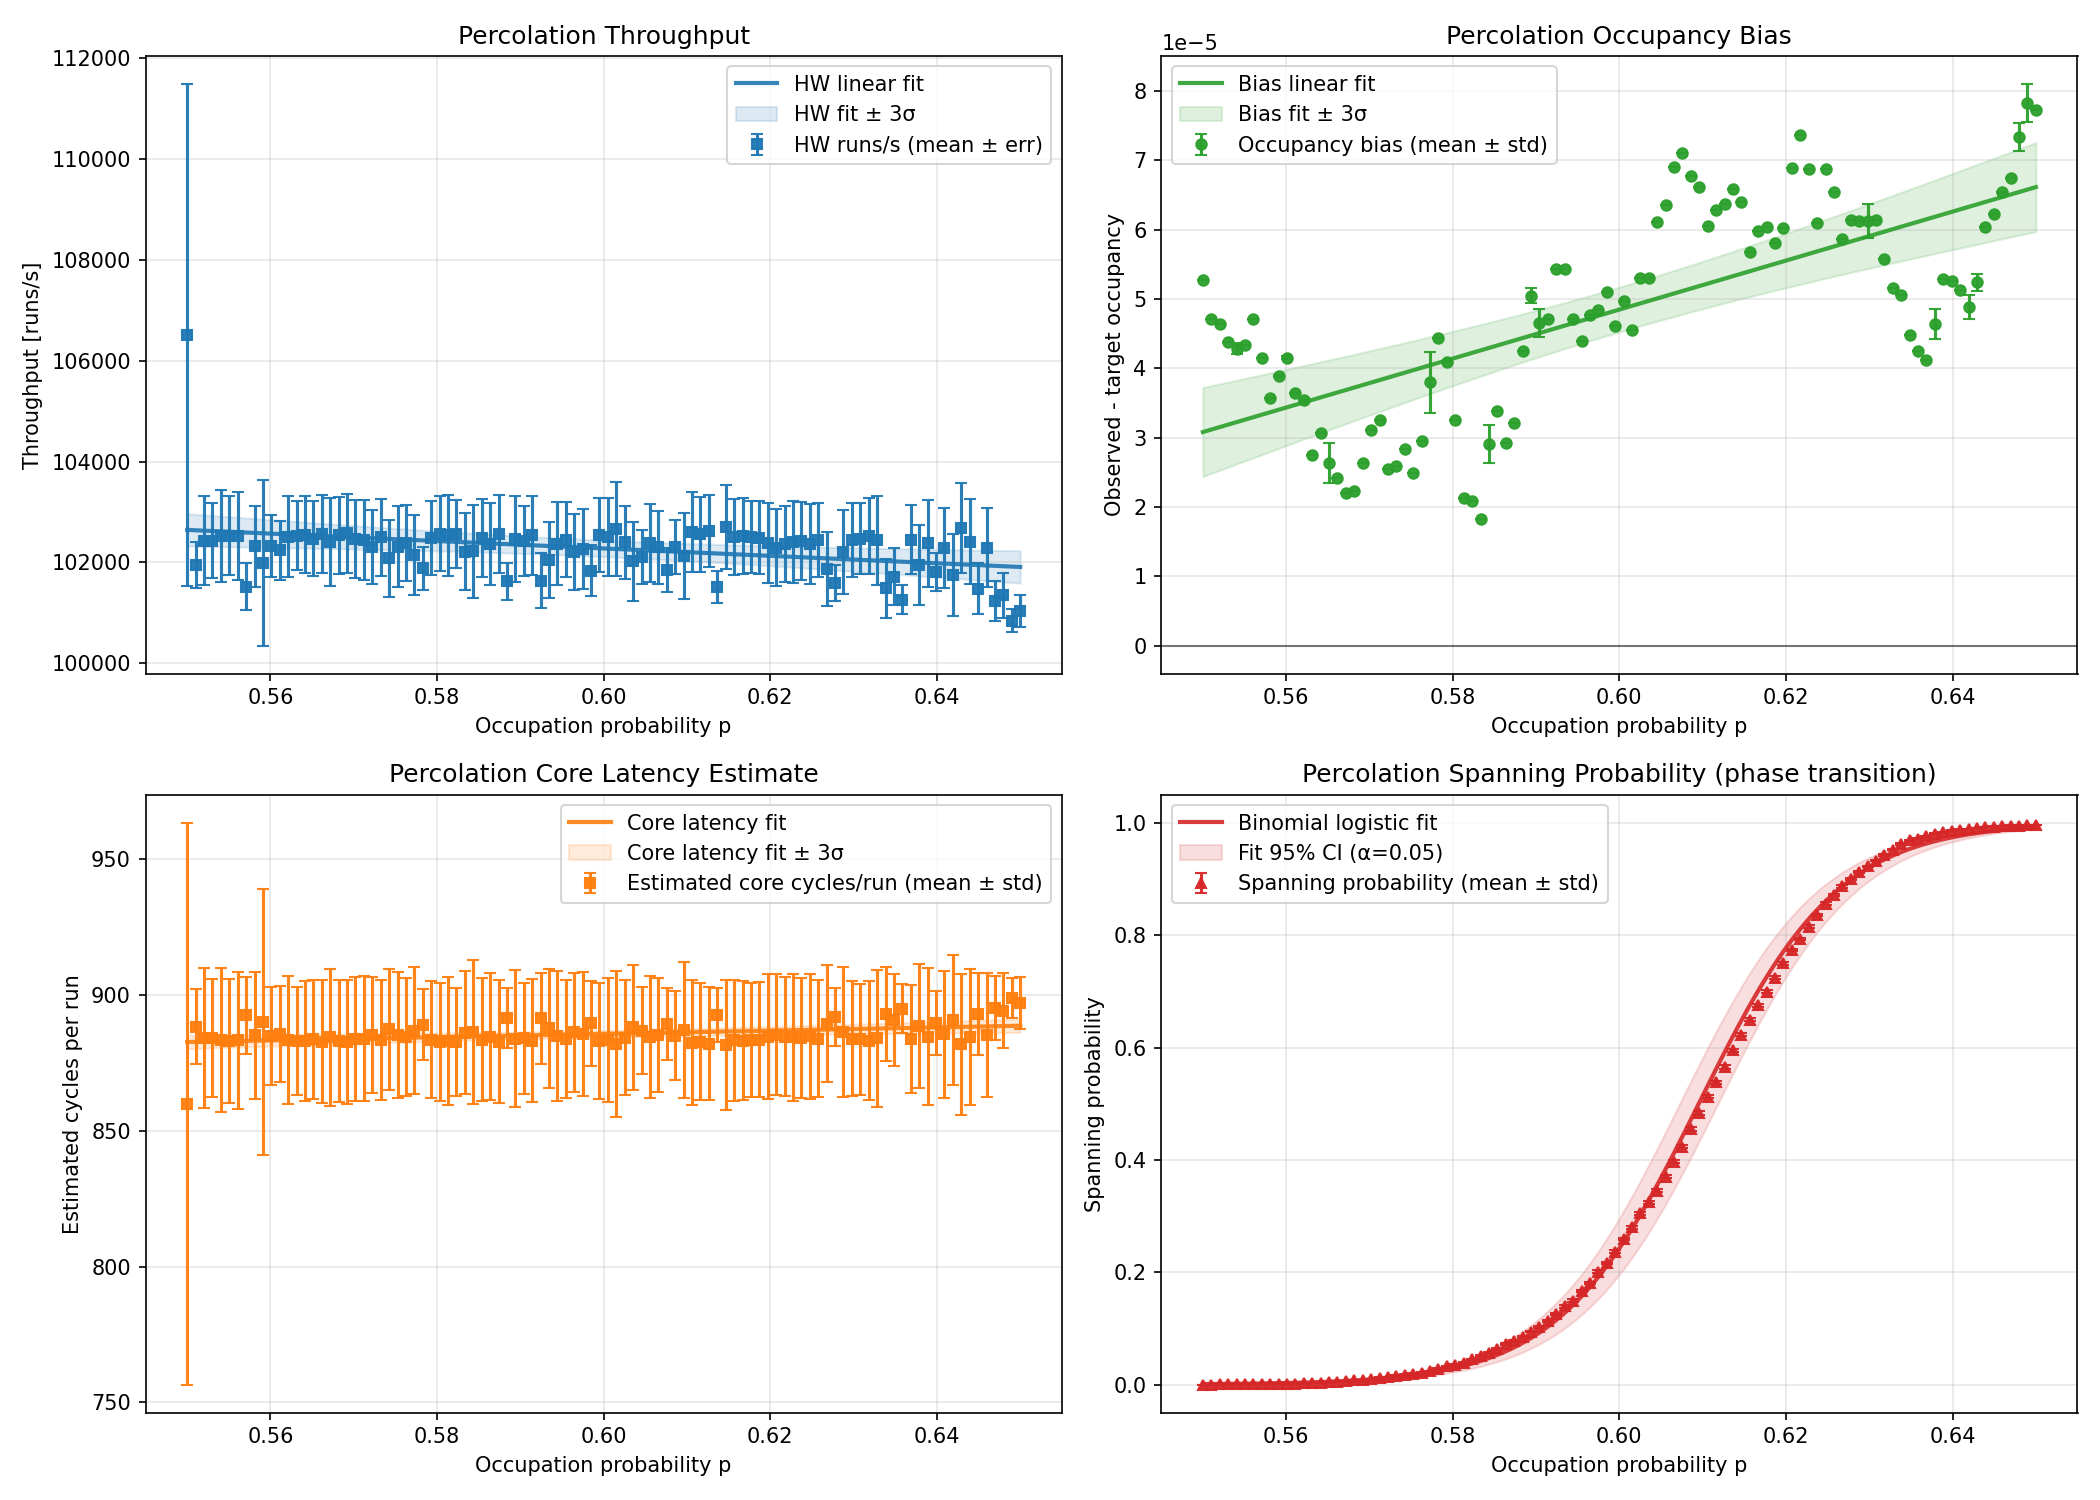

front_density.png


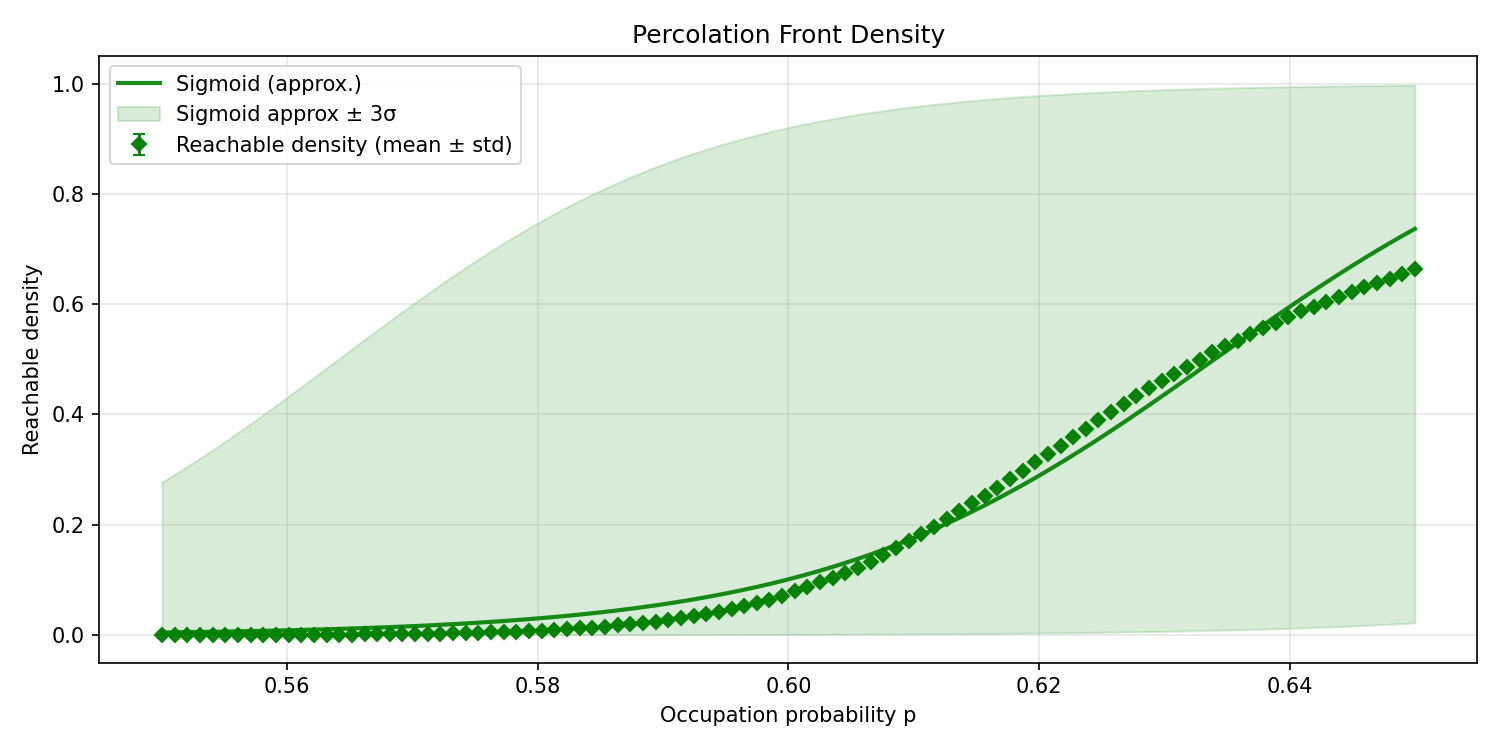

cluster_mass.png


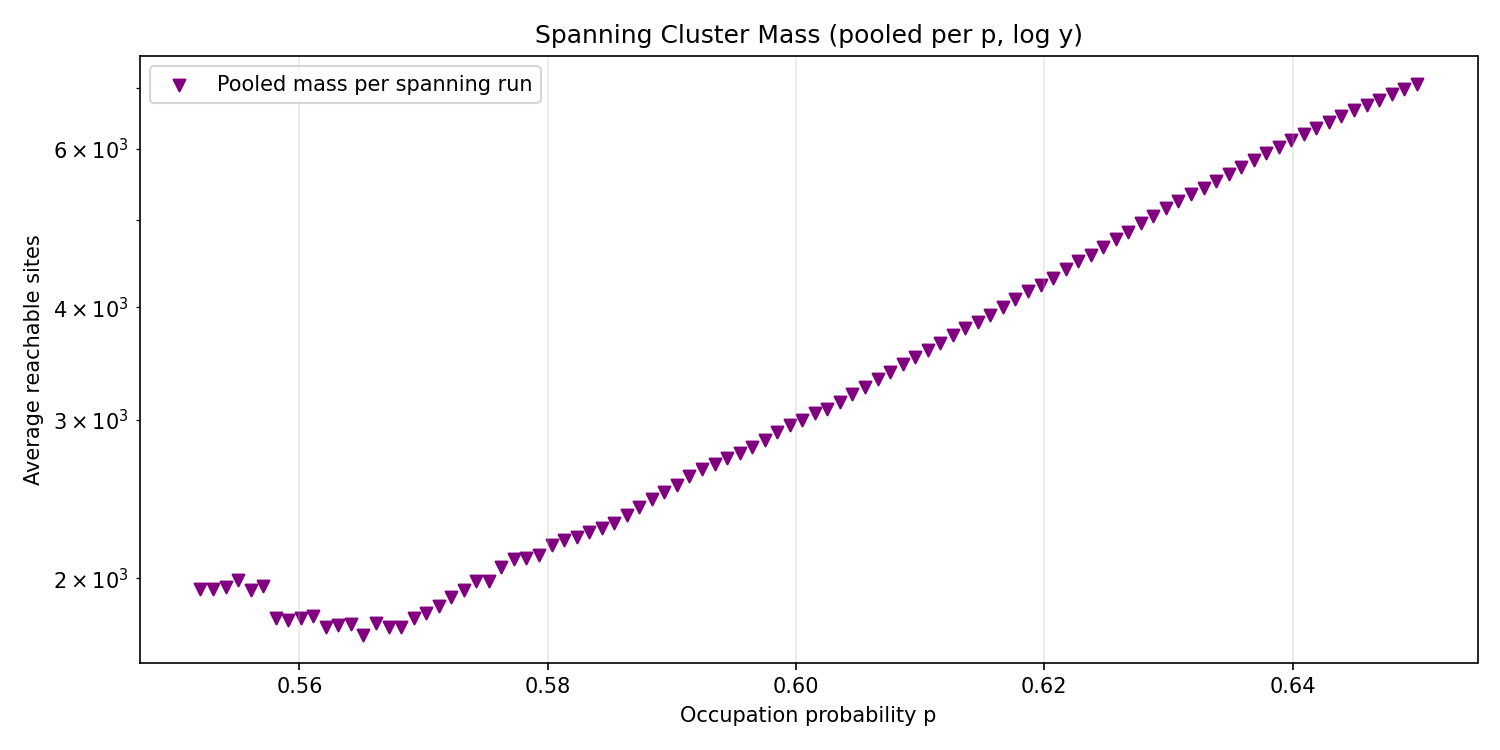

occupancy_bias.png


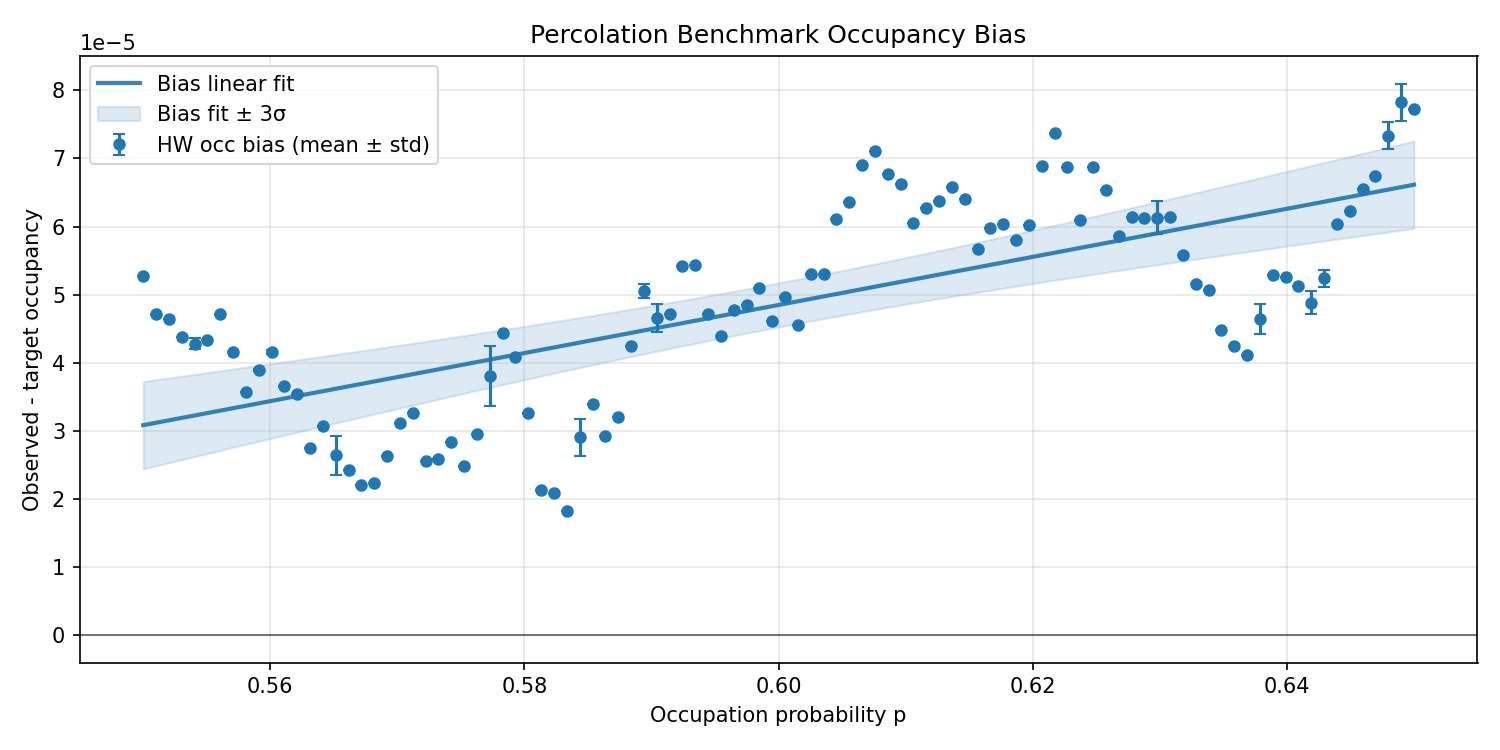

core_latency.png


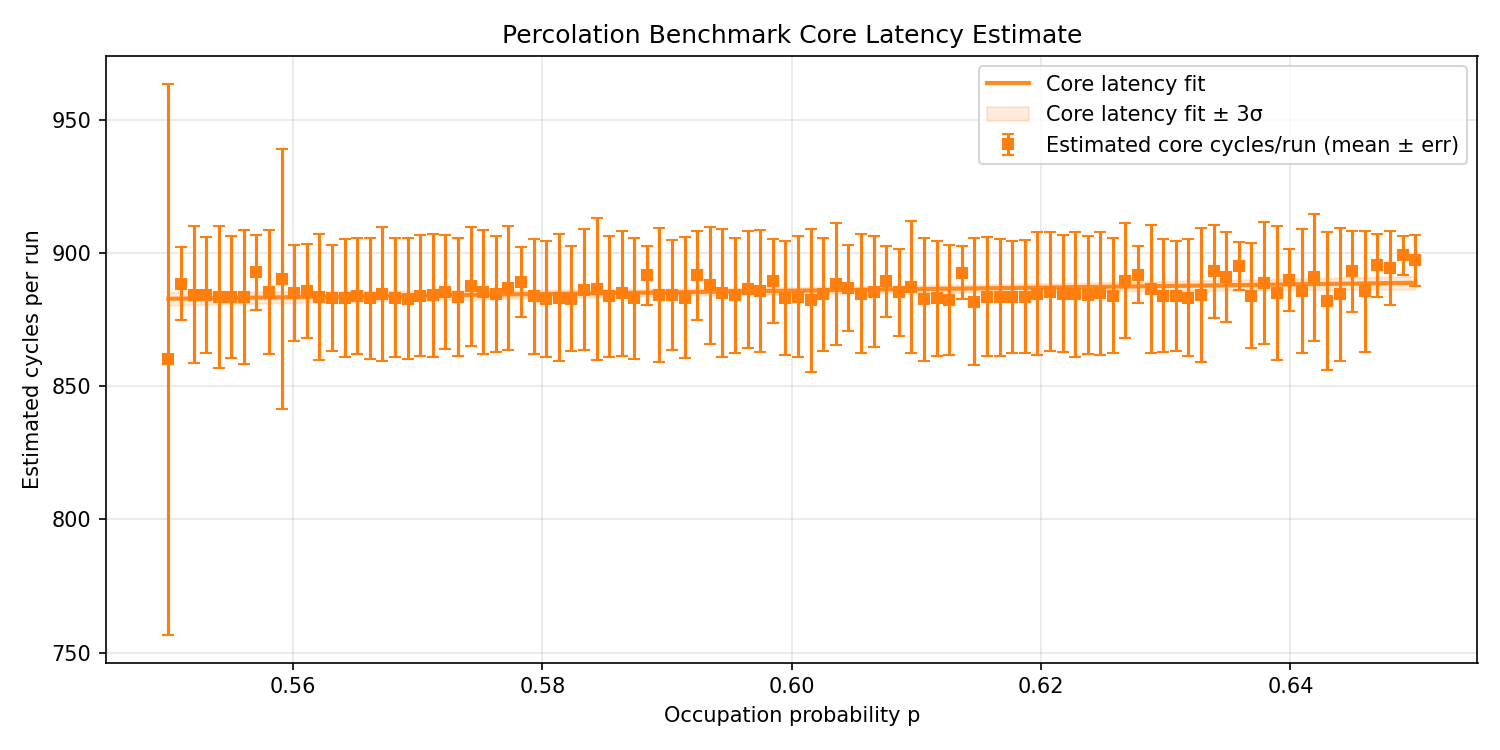

spanning_probability.png


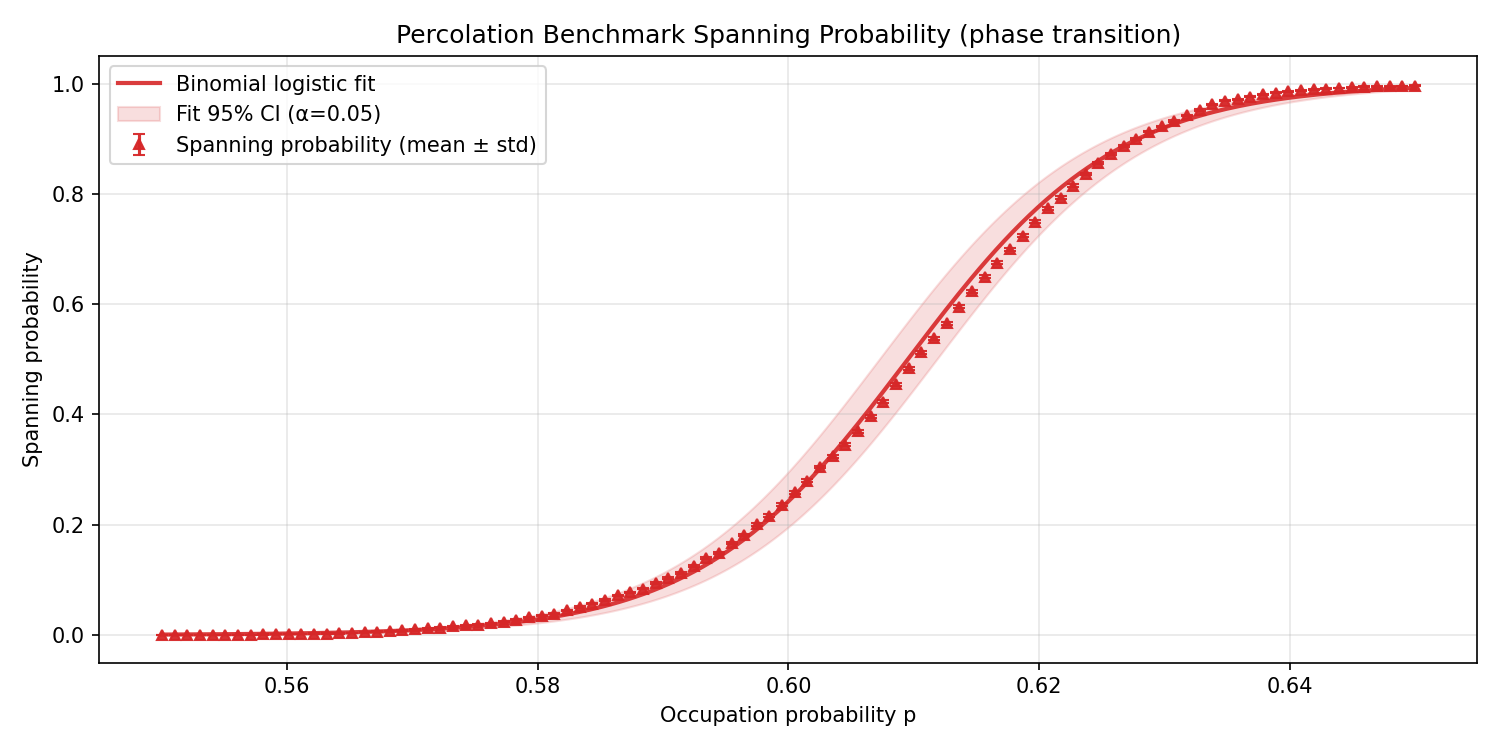

In [15]:
def render_png(path: Path) -> None:
    if not path.exists():
        print(f'missing: {path}')
        return
    display(Image(filename=str(path)))

session_plot_dir = plot_dir / selected_session_id
session_plot_dir.mkdir(parents=True, exist_ok=True)

analysis.plot_dashboard(summary_rows, raw_rows, session_plot_dir / 'dashboard.png')
analysis.plot_front_density(raw_rows, session_plot_dir / 'front_density.png')
analysis.plot_cluster_mass(raw_rows, session_plot_dir / 'cluster_mass.png')
analysis.plot_occupancy_bias(raw_rows, session_plot_dir / 'occupancy_bias.png')
analysis.plot_core_latency(raw_rows, session_plot_dir / 'core_latency.png')
analysis.plot_spanning_probability(raw_rows, session_plot_dir / 'spanning_probability.png')
plt.close('all')

for filename in [
    'dashboard.png',
    'front_density.png',
    'cluster_mass.png',
    'occupancy_bias.png',
    'core_latency.png',
    'spanning_probability.png',
]:
    print(filename)
    render_png(session_plot_dir / filename)

## Optional batch view

Change `selected_session_index` and rerun the selection and rendering cells to inspect another benchmark session.

If you want to compare several sessions at once, keep the analysis logic in the module and use a small loop here to render one subdirectory per session.

## Sweep Session Explorer

This section inspects the recent latency sweep sessions collected with fixed probability `p = 0.60` and compares them by `steps_per_run` and `cfg_runs`.

It stays inside the notebook so the analysis logic remains in `percolation_uart.analysis` while the notebook only orchestrates filtering and plotting.

In [16]:
SWEEP_RUNS = {1, 4, 16, 64, 256, 1024, 4096, 16384, 65600}
SWEEP_STEPS = {64, 128, 256, 512, 768, 1024, 2048}
SWEEP_WIDTHS = {64, 170, 128}

def _session_signature(summary_rows, raw_rows):
    if not raw_rows:
        return None
    first_row = raw_rows[0]
    return {
        'runs': int(first_row['runs']),
        'steps': int(first_row['steps']),
        'width': int(first_row.get('hw_width', first_row.get('width', 0))),
        'points': len(summary_rows),
        'raw_rows': len(raw_rows),
        'summary_rows': len(summary_rows),
        'p_values': sorted({float(row['p']) for row in summary_rows}),
    }

conn = analysis._connect(db_path)
try:
    sessions = analysis.list_sessions(conn)
    sweep_sessions = []
    for session in sessions:
        summary_rows = analysis.load_summary_rows(conn, session_id=session.session_id)
        raw_rows = analysis.load_raw_rows(conn, session_id=session.session_id)
        signature = _session_signature(summary_rows, raw_rows)
        if signature is None:
            continue
        if signature['runs'] not in SWEEP_RUNS:
            continue
        if signature['steps'] not in SWEEP_STEPS:
            continue
        if SWEEP_WIDTHS is not None and signature['width'] not in SWEEP_WIDTHS:
            continue
        sweep_sessions.append((session, signature, summary_rows, raw_rows))
finally:
    conn.close()

print(f'found {len(sweep_sessions)} sweep sessions')
for index, (session, signature, summary_rows, raw_rows) in enumerate(sweep_sessions[-12:], start=max(1, len(sweep_sessions) - 11)):
    print(f'{index:2d}. session_id={session.session_id} created_at={session.created_at}')
    print(f'    runs={signature["runs"]} steps={signature["steps"]} width={signature["width"]} summary_rows={signature["summary_rows"]} raw_rows={signature["raw_rows"]}')
    print(f'    p_values={signature["p_values"]}')

found 71 sweep sessions
60. session_id=d4060271-2a8b-4185-b222-68838336e0ad created_at=2026-05-25T20:36:06.420046+00:00
    runs=256 steps=1024 width=128 summary_rows=2 raw_rows=10
    p_values=[0.6]
61. session_id=b79037a5-25c5-461d-aac9-7b883820daea created_at=2026-05-25T20:36:07.487998+00:00
    runs=1024 steps=1024 width=128 summary_rows=2 raw_rows=10
    p_values=[0.6]
62. session_id=fdb77604-7c9c-4875-9c39-d51c0f2517f5 created_at=2026-05-25T20:36:09.771588+00:00
    runs=4096 steps=1024 width=128 summary_rows=2 raw_rows=10
    p_values=[0.6]
63. session_id=157e701d-021f-4785-b867-9bfa09870b29 created_at=2026-05-25T20:36:17.129171+00:00
    runs=16384 steps=1024 width=128 summary_rows=2 raw_rows=10
    p_values=[0.6]
64. session_id=f5f7a082-4a13-4dd6-9bc2-607c8907e3a5 created_at=2026-05-25T20:36:17.742244+00:00
    runs=1 steps=2048 width=128 summary_rows=2 raw_rows=10
    p_values=[0.6]
65. session_id=7186b111-9eff-490c-bdf8-b38bbceac1d2 created_at=2026-05-25T20:36:18.307523+00:0

In [17]:
    ideal_core_cycles = steps * analysis.FRONTIER_CYCLES_PER_STEP + 3.0

## FPGA Engineering Analysis

This section uses `benchmark-2.sqlite3` (the systematic runs/step sweeps) to
produce FPGA-performance plots. Each plot is generated via `analysis.py` and
displayed inline.

The plots cover:
- **Latency vs Batch**: Amdahl-style speedup, showing how UART overhead gets amortized
- **Breakdown + Throughput**: Side-by-side asymptotic decomposition — core cycles/run
  (fixed + marginal cost) and throughput in rows/s (Amdahl saturation)
- **Asymptotic Breakdown**: Separates fixed (host+UART) from marginal (FPGA core) cost
- **Pipeline Efficiency**: How close the frontier pipeline is to the ideal 3 cyc/step
- **Throughput Invariance**: Throughput stability across grid heights, with asymptotic
  rows/s fits (cells/s left, asymptotic throughput right)
- **Throughput Contour**: 2D heatmap of performance
- **Determinism CV**: Coefficient of variation across repeats

Run all cells below to generate and view the plots.


### FPGA Engineering: Latency vs Batch Size & Amdahl Speedup

Left panel: total latency vs batch size (log-log). Flat at small R (UART-dominated),
linear once core time dominates. Right panel: speedup relative to R=1. The
annotated `f_serial` is the Amdahl serial fraction — the irreducible UART overhead.

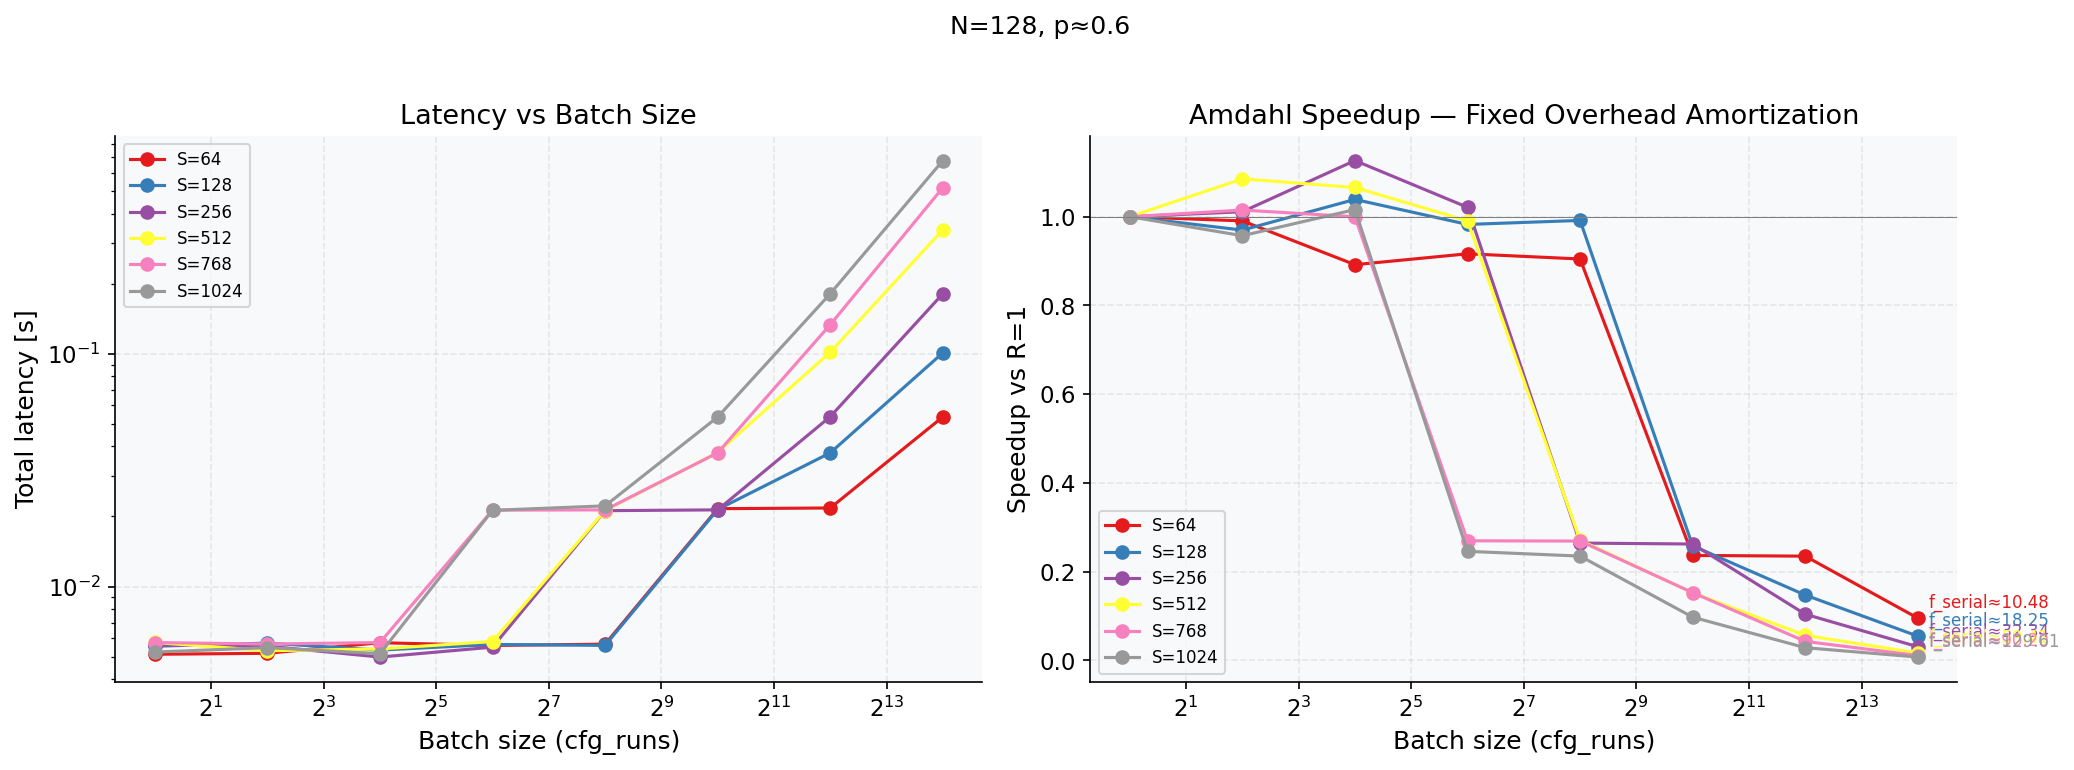

In [18]:
from percolation_uart import analysis
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Image, display

db2_path = repo_root / 'python' / 'output' / 'benchmark-2.sqlite3'
conn2 = analysis._connect(db2_path)
fpga_out = plot_dir / 'fpga_engineering'
fpga_out.mkdir(parents=True, exist_ok=True)

# 1. Latency vs Batch
analysis.plot_latency_vs_batch(conn2, fpga_out / 'latency_vs_batch.png')
display(Image(filename=str(fpga_out / 'latency_vs_batch.png')))

### FPGA Engineering: Breakdown vs Throughput (side by side)

Left panel: asymptotic cycles-per-run decomposition (core cycles/run → marginal cost).
Right panel: the same fit expressed as Amdahl throughput saturation in rows/s, with the
asymptote `steps×f_clk / C_marginal` as the batch size R→∞.



=== Breakdown vs Throughput (N=128, p≈0.6) ===
 steps  C_marginal     C_fixed    ideal(S×3)   overhead    util   asympt rows/s
----------------------------------------------------------------------------
    64       287.7      767065         192.0       95.7   66.7%        22242557
   128       582.4      757545         384.0      198.4   65.9%        21977360
   256      1059.1      847361         768.0      291.1   72.5%        24171779
   512      2040.0      983435        1536.0      504.0   75.3%        25098222
   768      3103.4      887340        2304.0      799.4   74.2%        24746914
  1024      4081.5     1002357        3072.0     1009.5   75.3%        25088894


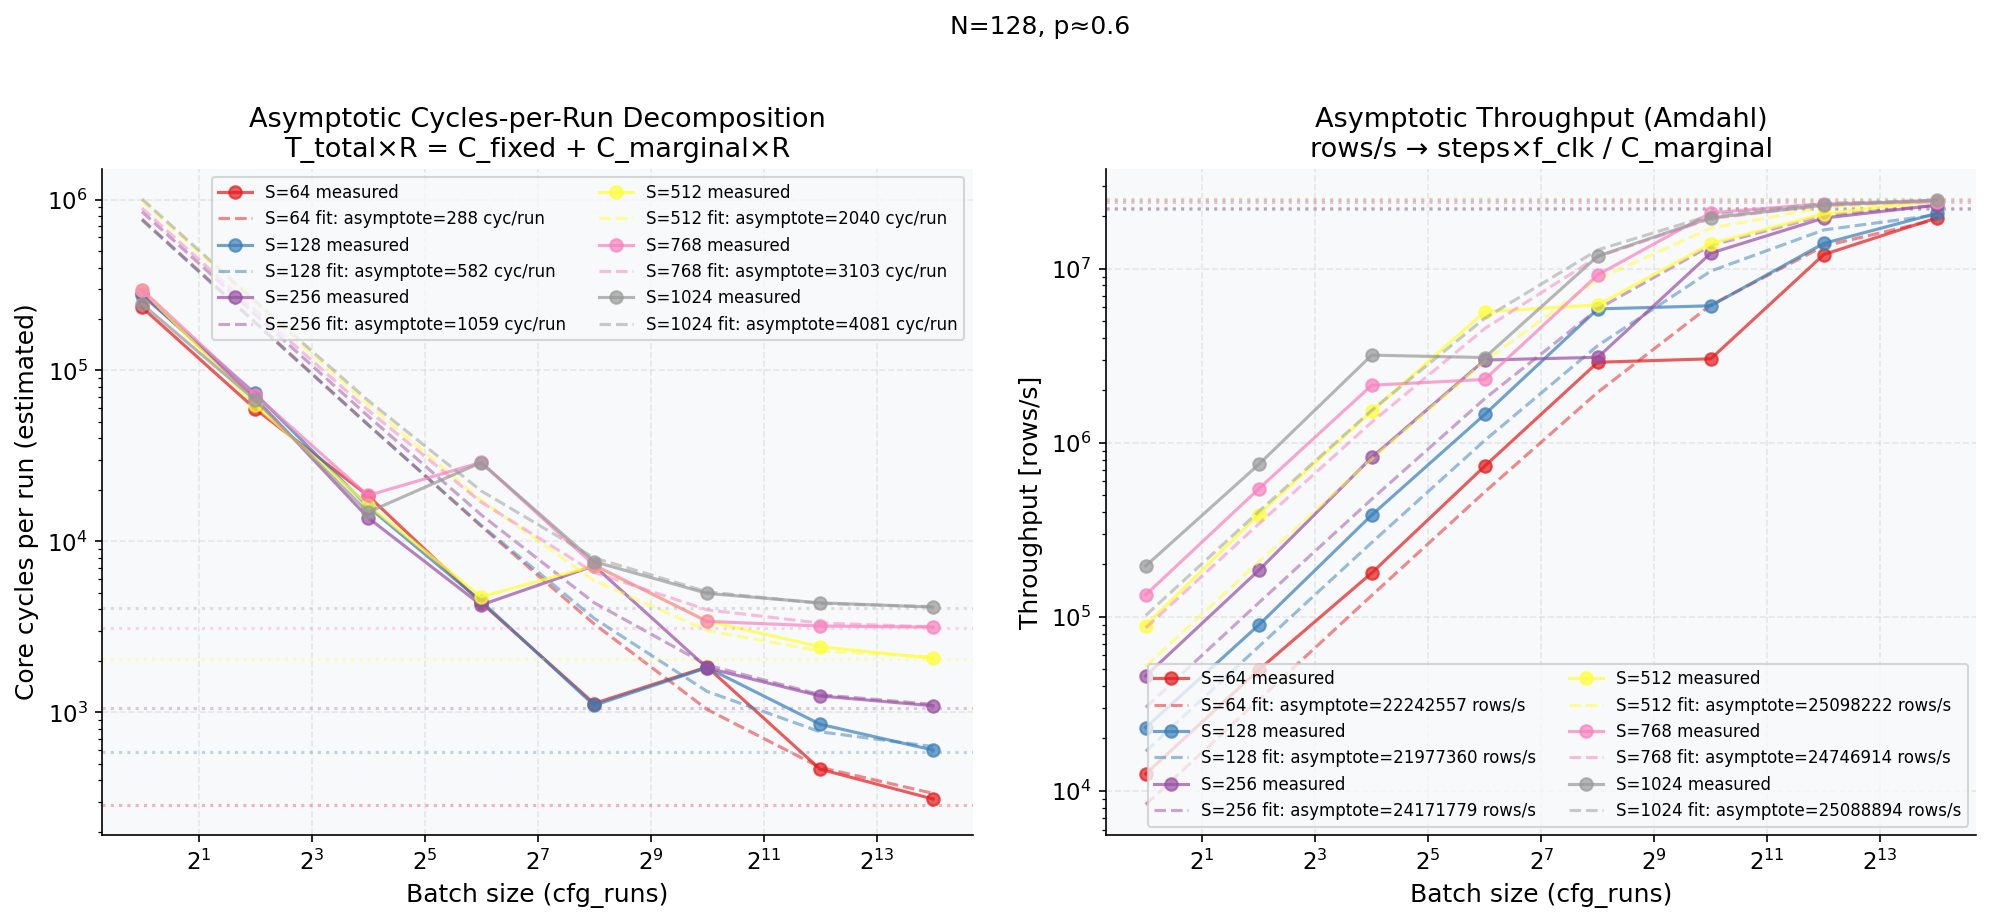


=== Asymptotic Fit Results (N=128, p≈0.6) ===
 steps  C_marginal     C_fixed    ideal(S×3)   overhead    util
-----------------------------------------------------
    64       287.7      767065         192.0       95.7   66.7%
   128       582.4      757545         384.0      198.4   65.9%
   256      1059.1      847361         768.0      291.1   72.5%
   512      2040.0      983435        1536.0      504.0   75.3%
   768      3103.4      887340        2304.0      799.4   74.2%
  1024      4081.5     1002357        3072.0     1009.5   75.3%


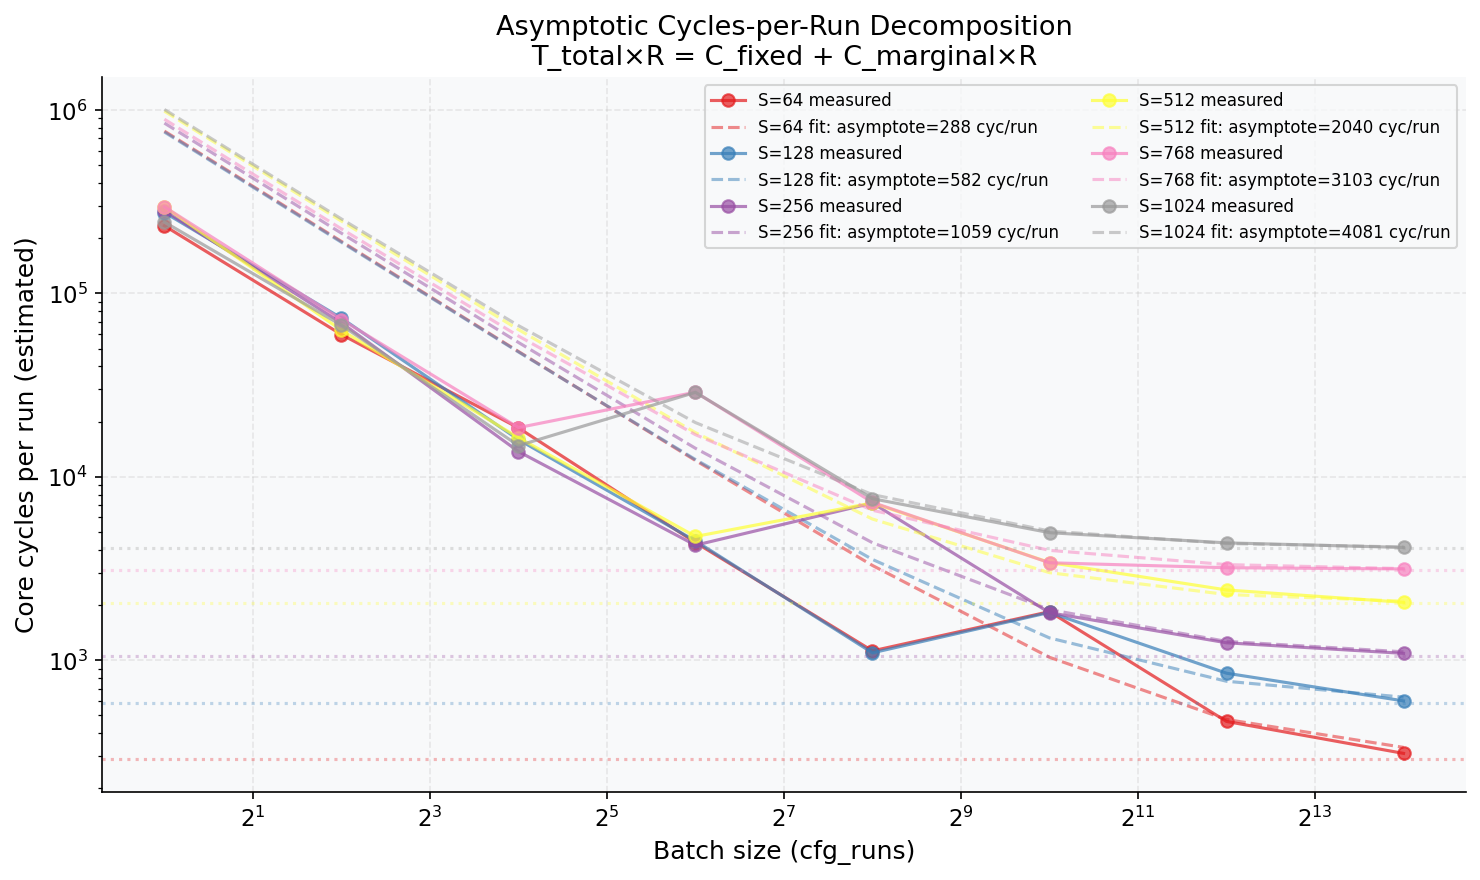


=== Pipeline Efficiency (N=128, R=16384, p≈0.6) ===
  Fit: C_core/run = 3.962 × steps + 71.0
  Ideal frontier: 3 cyc/step
  Per-step cost:  3.962 cyc/step (vs ideal 3, excess 0.962/step)
  Fixed overhead: 71.0 cyc/run

    S=  64: measured=310  ideal=263  excess=47  efficiency=84.8%
    S= 128: measured=600  ideal=455  excess=145  efficiency=75.9%
    S= 256: measured=1089  ideal=839  excess=250  efficiency=77.0%
    S= 512: measured=2067  ideal=1607  excess=460  efficiency=77.7%
    S= 768: measured=3145  ideal=2375  excess=770  efficiency=75.5%
    S=1024: measured=4118  ideal=3143  excess=975  efficiency=76.3%


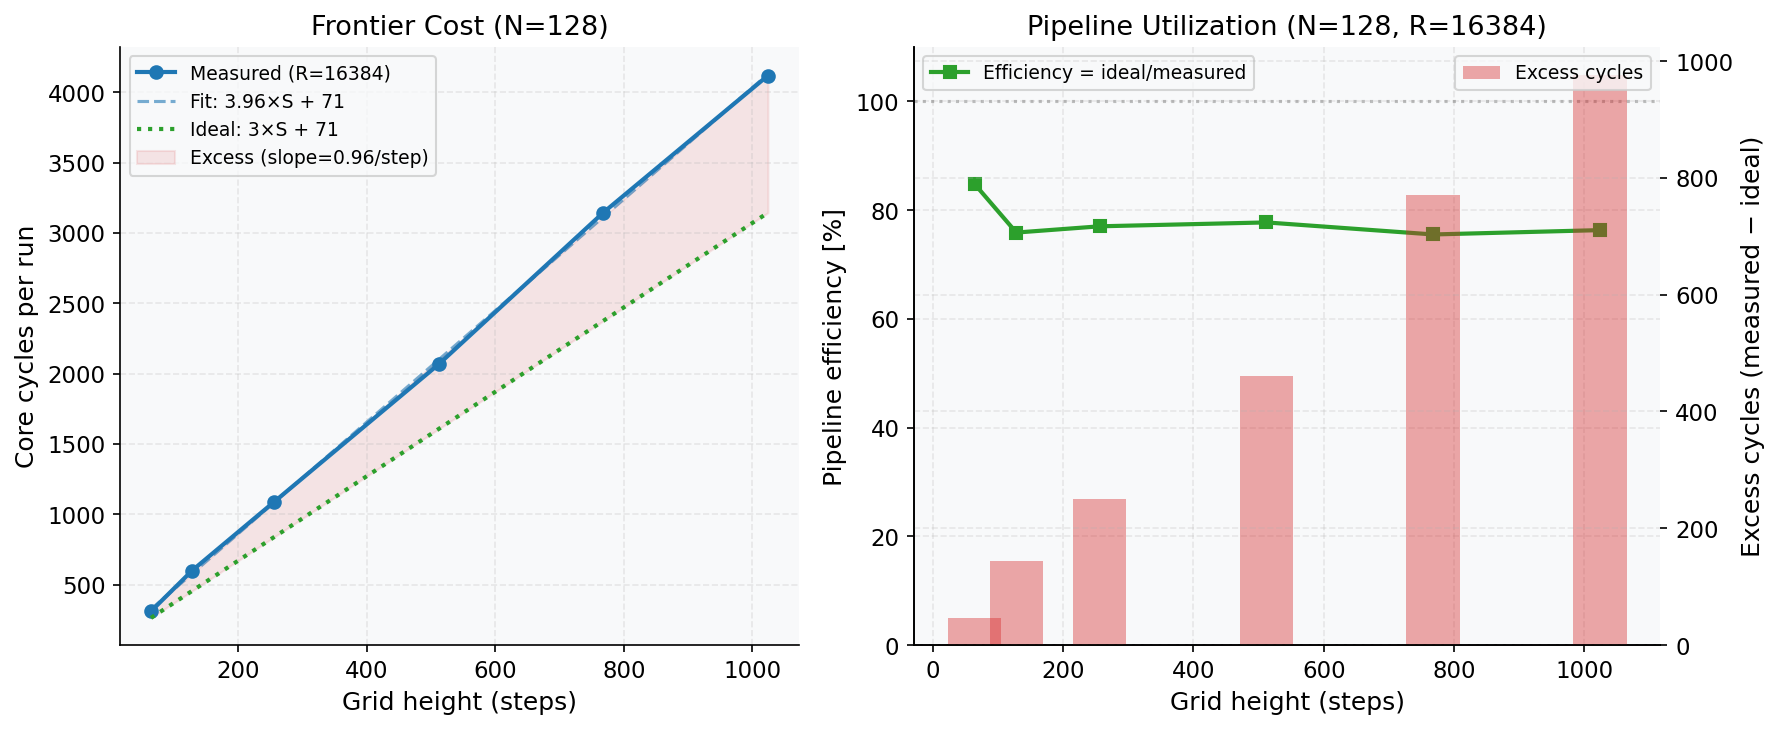

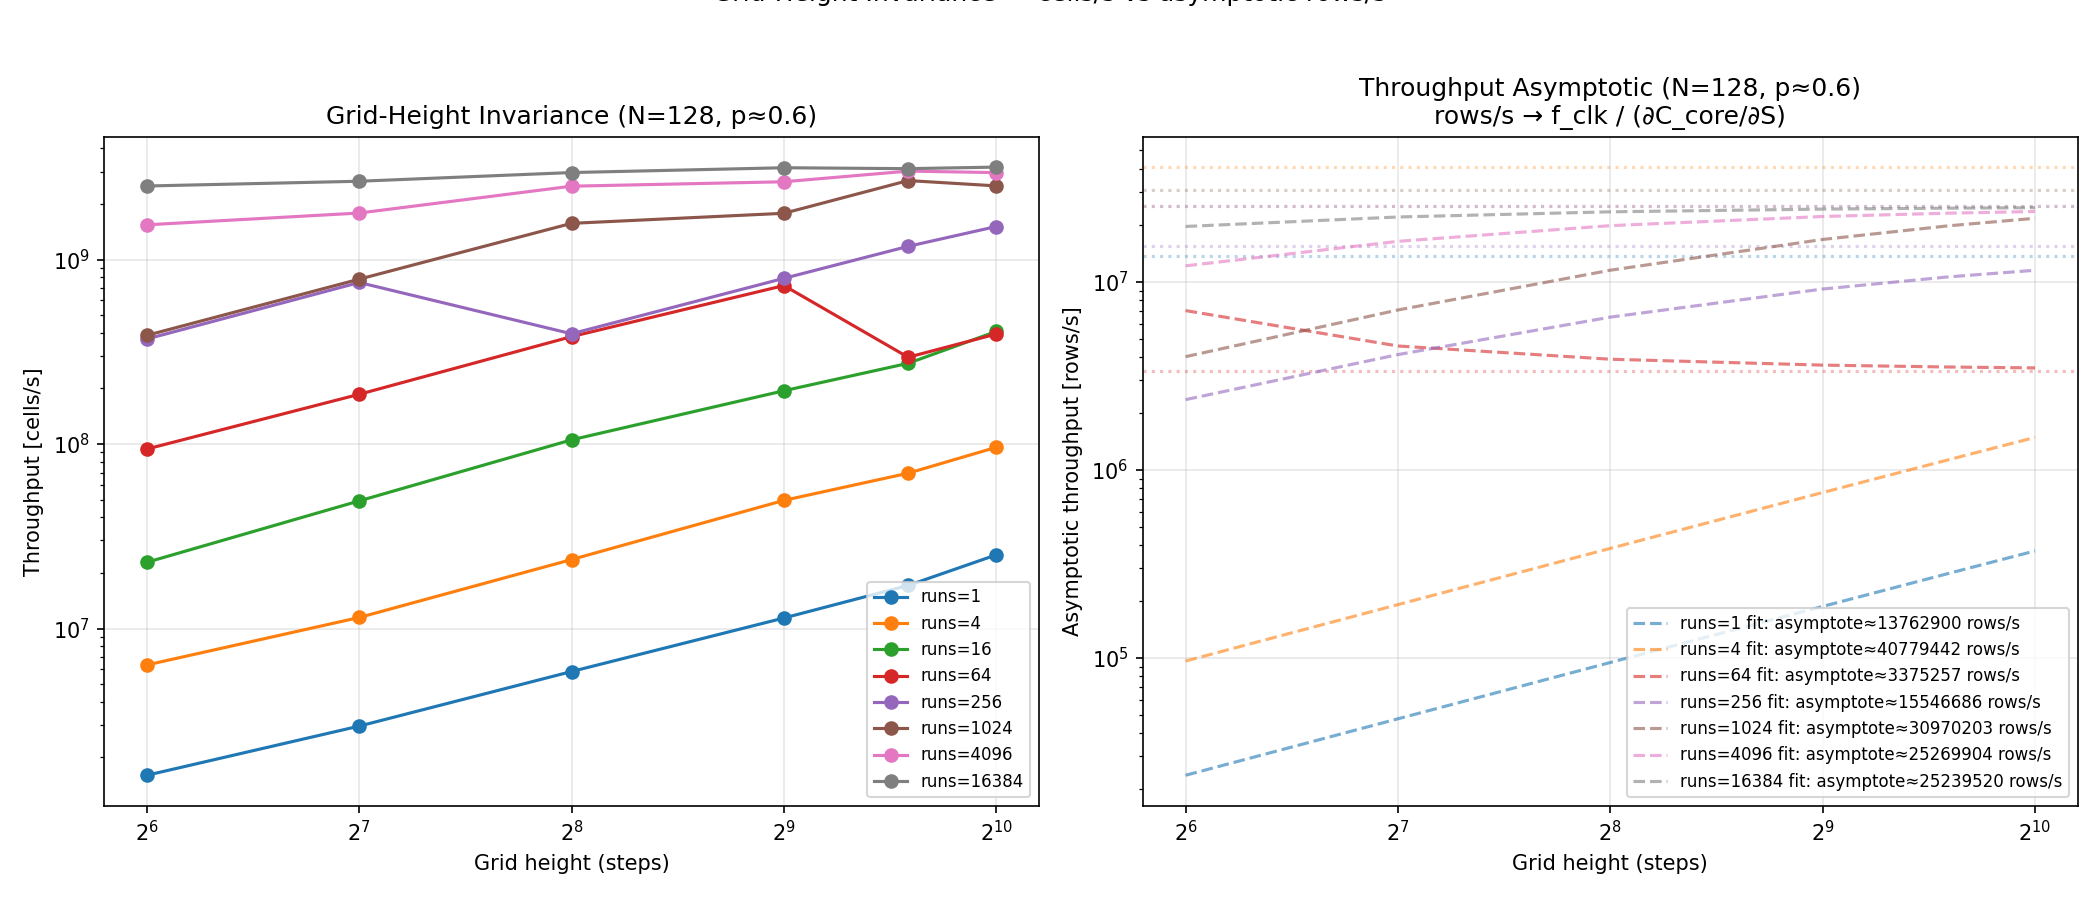

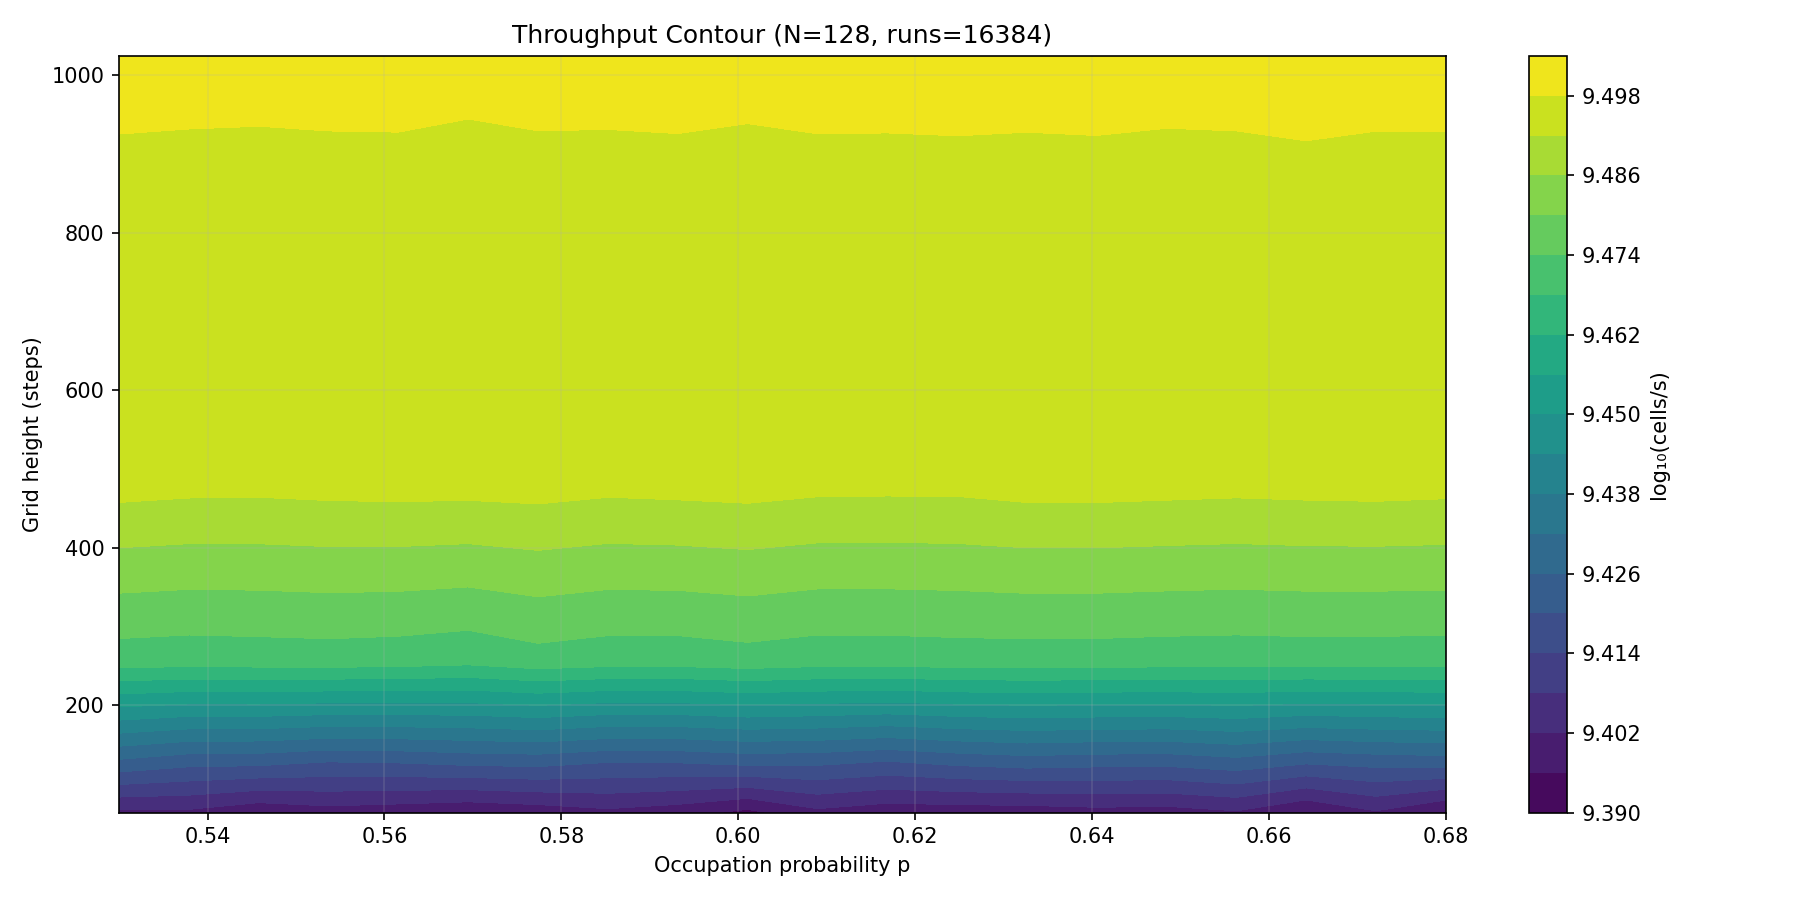


=== Determinism CV (N=128) ===
  steps=  64 runs=     1  CV=5.10%
  steps=  64 runs=     4  CV=5.80%
  steps=  64 runs=    16  CV=5.18%
  steps=  64 runs=    64  CV=6.52%
  steps=  64 runs=   256  CV=7.39%
  steps=  64 runs=  1024  CV=40.36%
  steps=  64 runs=  4096  CV=1.49%
  steps=  64 runs= 16384  CV=0.52%
  steps= 128 runs=     1  CV=7.03%
  steps= 128 runs=     4  CV=4.95%
  steps= 128 runs=    16  CV=6.40%
  steps= 128 runs=    64  CV=5.04%
  steps= 128 runs=   256  CV=6.54%
  steps= 128 runs=  1024  CV=1.29%
  steps= 128 runs=  4096  CV=0.80%
  steps= 128 runs= 16384  CV=0.29%
  steps= 256 runs=     1  CV=5.09%
  steps= 256 runs=     4  CV=6.39%
  steps= 256 runs=    16  CV=4.03%
  steps= 256 runs=    64  CV=5.19%
  steps= 256 runs=   256  CV=1.39%
  steps= 256 runs=  1024  CV=1.26%
  steps= 256 runs=  4096  CV=0.55%
  steps= 256 runs= 16384  CV=0.16%
  steps= 512 runs=     1  CV=3.54%
  steps= 512 runs=     4  CV=5.50%
  steps= 512 runs=    16  CV=4.55%
  steps= 512 runs=    

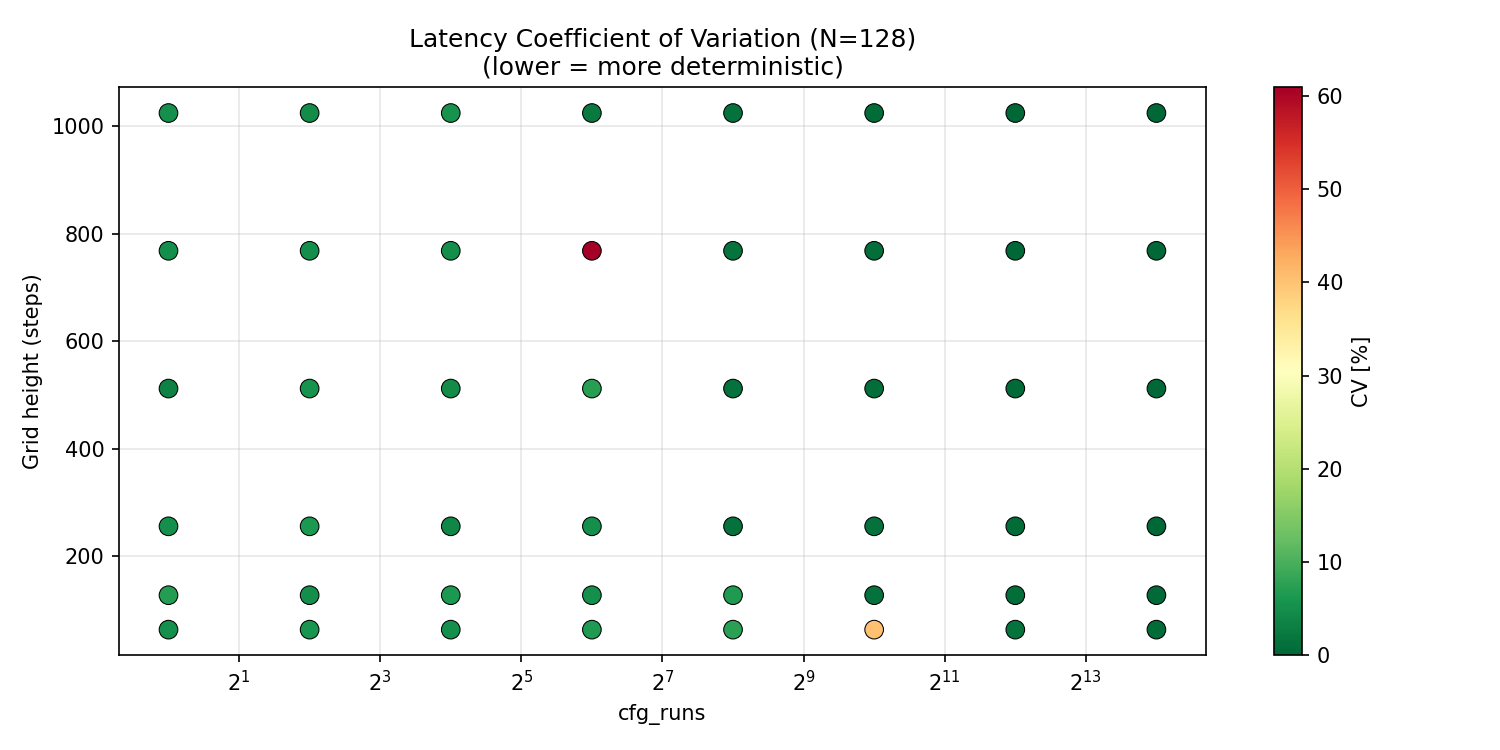

In [19]:
# Breakdown vs Throughput (side by side)
analysis.plot_breakdown_throughput(conn2, fpga_out / 'breakdown_throughput.png')
display(Image(filename=str(fpga_out / 'breakdown_throughput.png')))

# Asymptotic Breakdown
analysis.plot_breakdown_fit(conn2, fpga_out / 'breakdown_fit.png')
display(Image(filename=str(fpga_out / 'breakdown_fit.png')))

# Pipeline Efficiency
analysis.plot_pipeline_efficiency(conn2, fpga_out / 'pipeline_efficiency.png')
display(Image(filename=str(fpga_out / 'pipeline_efficiency.png')))

# Throughput Invariance
analysis.plot_throughput_invariance(conn2, fpga_out / 'throughput_invariance.png')
display(Image(filename=str(fpga_out / 'throughput_invariance.png')))

# Throughput Contour
analysis.plot_throughput_contour(conn2, fpga_out / 'throughput_contour.png')
display(Image(filename=str(fpga_out / 'throughput_contour.png')))

# Determinism CV (N=128)
analysis.plot_determinism_cv(conn2, fpga_out / 'determinism_cv.png', hw_width=128)
display(Image(filename=str(fpga_out / 'determinism_cv.png')))

conn2.close()

## Physics / DP Analysis

Three plots probing the directed percolation phase transition:

1. **Finite-Size Scaling**: Spanning probability curves for square grids
   N=64×64, 128×128, 180×180 with approximate data collapse
2. **Threshold Bootstrap**: Binomial logistic fit restricted to the transition
   region (0.001 < P_span < 0.999). Bootstrap via Binomial(n, p̂) resampling.
3. **Cluster Mass Curves**: Average reachable sites per spanning run vs p —
   a continuous order parameter that diverges near p_c.

All use `benchmark-2.sqlite3` (square-grid sessions only).


=== Finite-Size Scaling (square grids) ===
  N=64×64:  session=d1c5b94d  total_runs=327680
  N=128×128:  session=b76d637d  total_runs=327680
  N=180×180:  session=ba1fe7e8  total_runs=6553600
  p_c estimates: ['0.6038', '0.6098', '0.6124']
  Using p_c=0.6124 for collapse


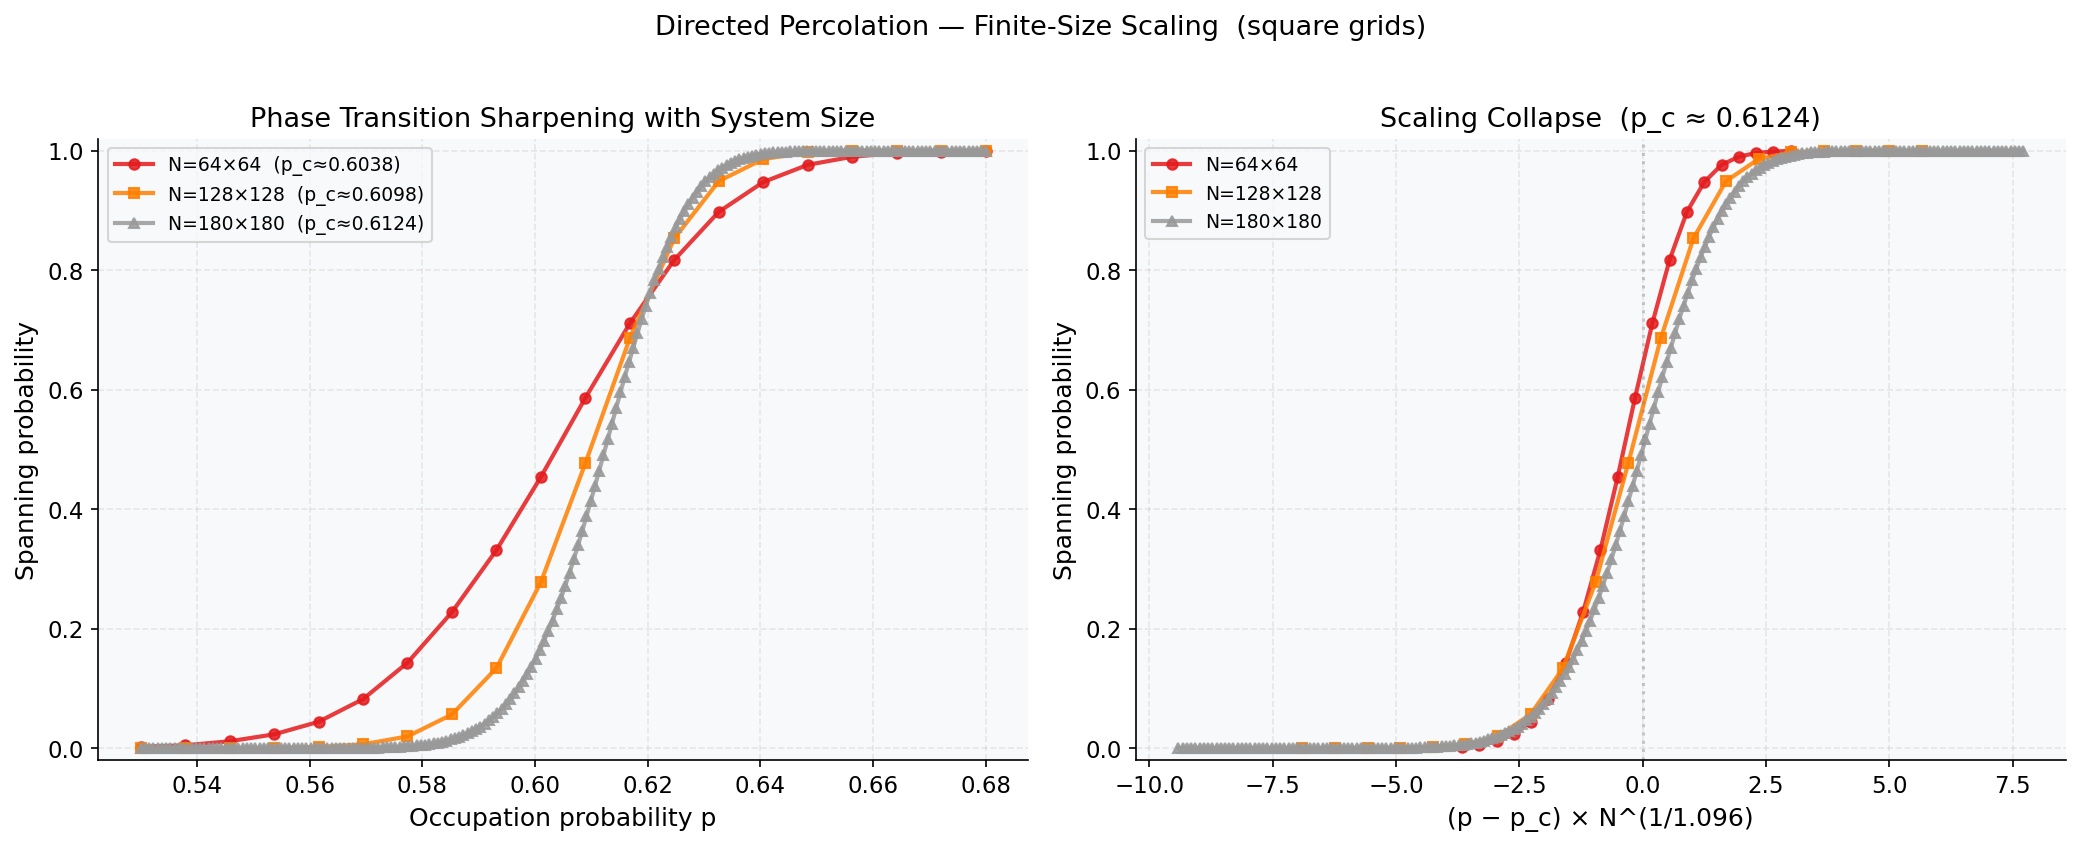


=== Threshold Estimation (N=180, 2000 binomial bootstrap) ===
  Fit range: 0.5730 – 0.6461  (98 points)
  Logistic: a=169.1, b=-103.4
  p_c = −b/a = 0.611177
  Slope at p_c = a/4 = 42.3
  Bootstrap: median=0.611178, mean=0.611470
  95% CI: [0.611172, 0.612079]
  CI width: 0.000906


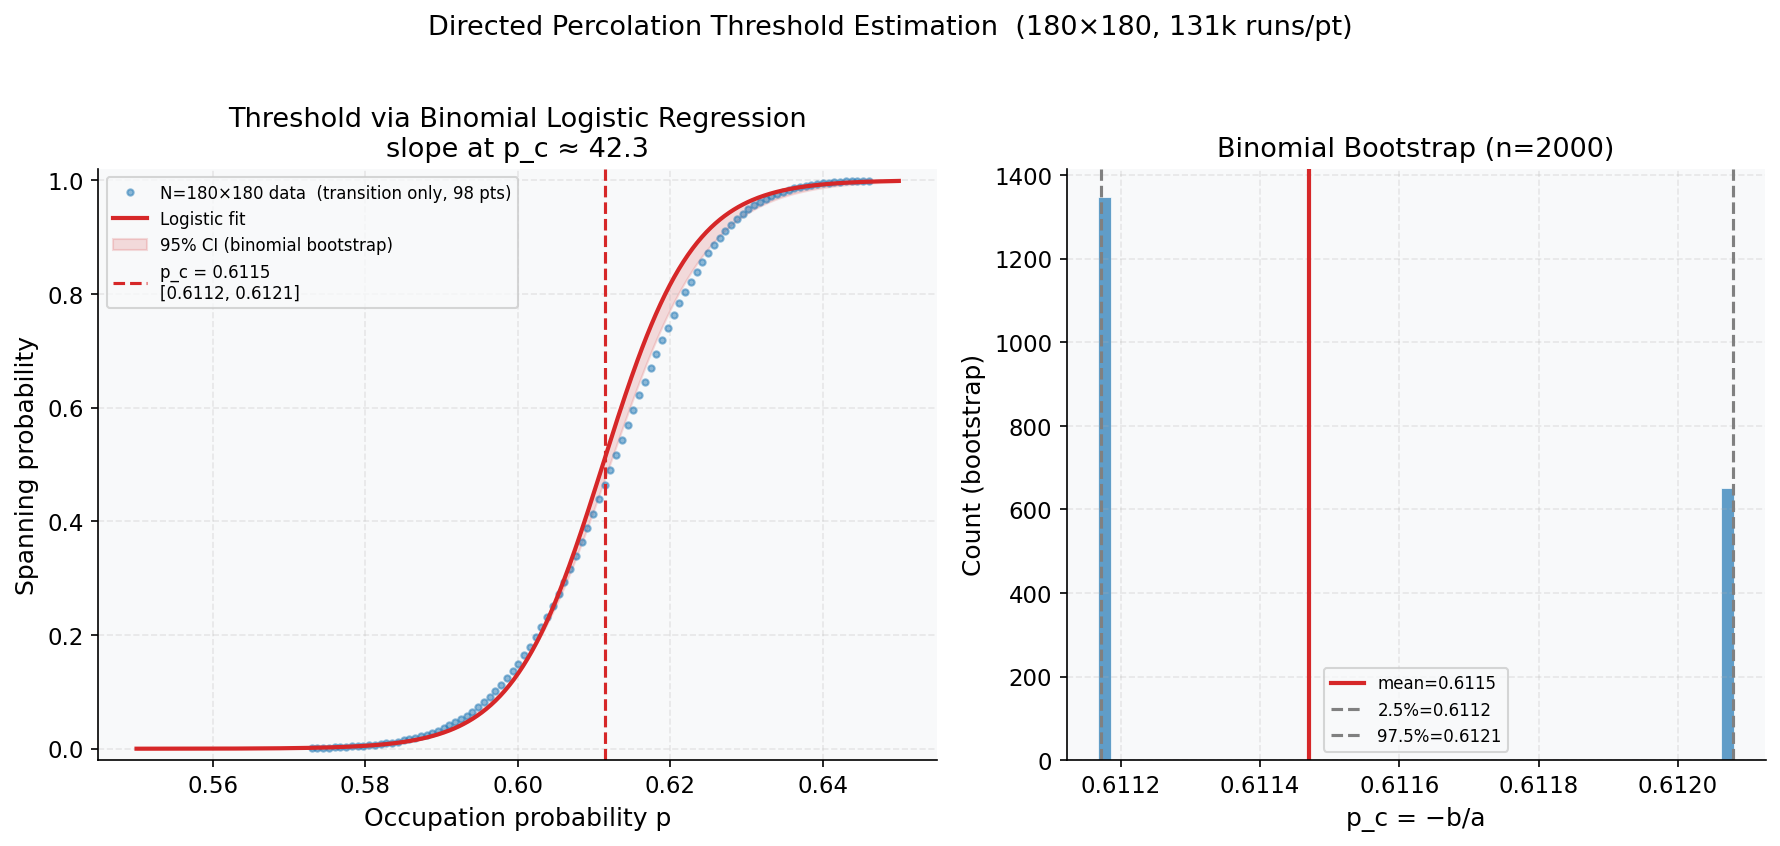

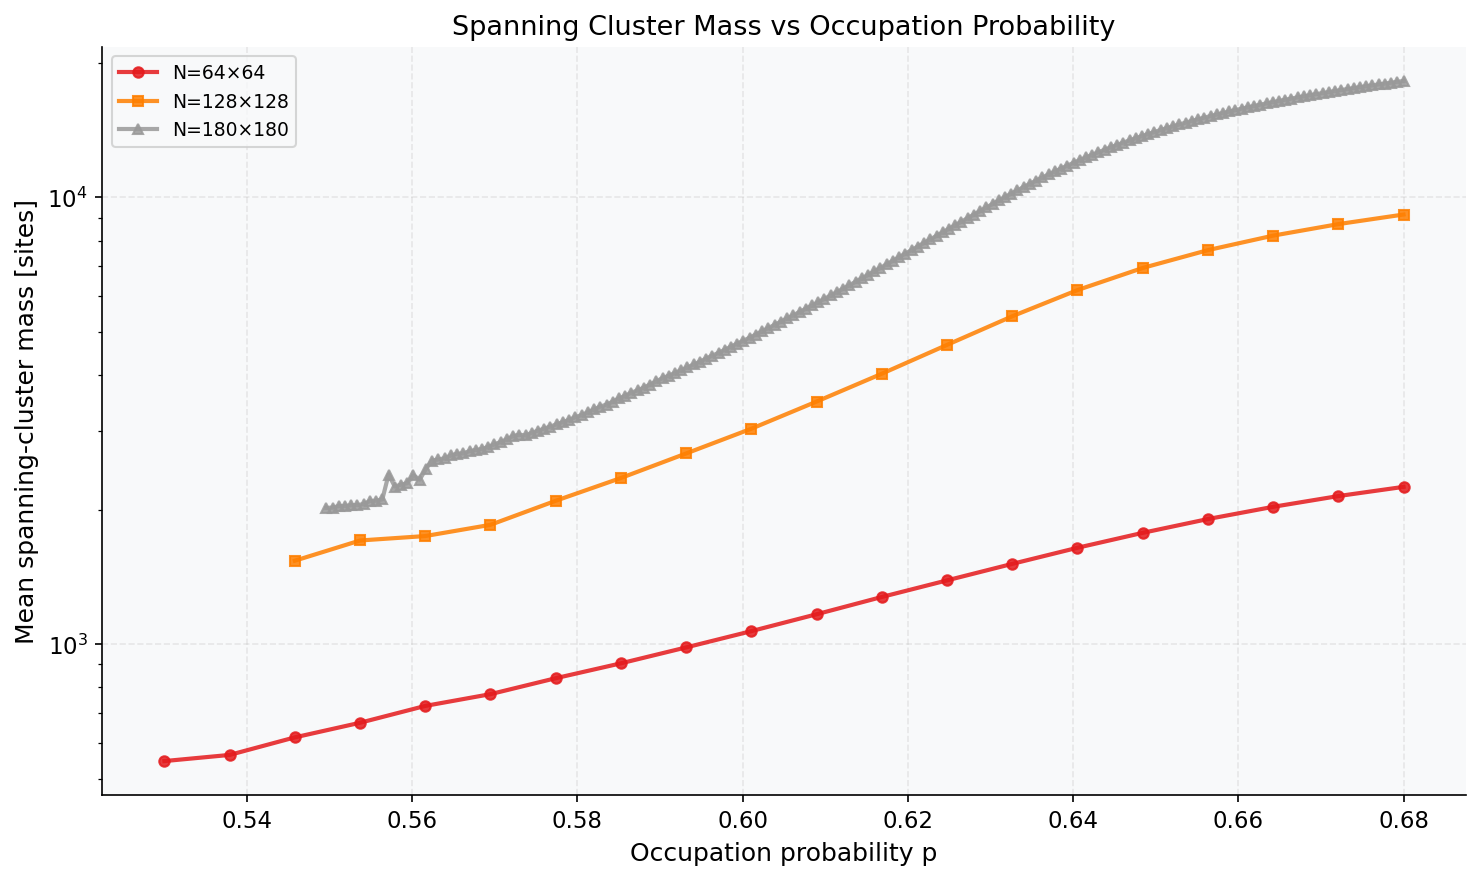

Physics plots generated.


In [20]:
import matplotlib.pyplot as plt
from IPython.display import Image, display

db2_path = repo_root / 'python' / 'output' / 'benchmark-2.sqlite3'
conn2 = analysis._connect(db2_path)
physics_out = plot_dir / 'physics'
physics_out.mkdir(parents=True, exist_ok=True)

# 1. Finite-Size Scaling
analysis.plot_spanning_curves_multi_size(conn2, physics_out / 'finite_size_scaling.png')
display(Image(filename=str(physics_out / 'finite_size_scaling.png')))

# 2. Threshold Bootstrap (transition-region fit, binomial resampling)
analysis.plot_threshold_bootstrap(conn2, physics_out / 'threshold_bootstrap.png')
display(Image(filename=str(physics_out / 'threshold_bootstrap.png')))

# 3. Cluster Mass Curves (continuous observable, replaces Binder cumulant)
analysis.plot_cluster_mass_curves(conn2, physics_out / 'cluster_mass_curves.png')
display(Image(filename=str(physics_out / 'cluster_mass_curves.png')))

conn2.close()

print('Physics plots generated.')